# SSSP: Delta-Stepping — LAGraph (CPU) vs SPLA (GPU)

## Algorithm
LAGraph `LAGr_SingleSourceShortestPath` — delta-stepping algorithm (Meyer & Sanders 2003).  
Graphs: unit-weight (all bool→float 1.0 via `GrB_IDENTITY_FP32`).  
Delta = 1.0 → all edges are "light" → degenerates toward BFS-like relaxation;  
this is intentional to benchmark the implementation, not a specific delta value.

## Directed vs Undirected
- **LAGraph SSSP**: supports both. Directed uses out-edges of each vertex (forward relaxation).
- **SPLA SSSP**: requires `--undirected=true` — the push/pull hybrid needs bidirectional access.
  Running SPLA SSSP on a directed graph produces incorrect results.

## Source selection
Max-out-degree node, selected dynamically. Maximises reachable nodes and is consistent
with LAGraph benchmark suite conventions.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')

REPO = Path('../../')
RESULTS = REPO / 'lagraph-spla' / 'results' / 'sssp'
PICS    = REPO / 'lagraph-spla' / 'presentation' / 'pictures' / 'sssp'
PICS.mkdir(parents=True, exist_ok=True)

GRAPH_EDGES = {
    'soc-LiveJournal1.mtx': 68_993_773,
    'patents.mtx':          14_970_767,
    'wiki-Talk.mtx':         5_021_410,
    'rgg_n_2_22_s0.mtx':   29_360_162,
}
NAME_MAP = {
    'soc-LiveJournal1.mtx': 'LiveJournal',
    'patents.mtx':          'Patents',
    'wiki-Talk.mtx':        'wiki-Talk',
    'rgg_n_2_22_s0.mtx':   'RGG',
}
ORDER_MODES  = ['LAGraph directed', 'LAGraph undirected', 'SpLA GPU']
GRAPHS_ORDER = ['LiveJournal', 'wiki-Talk', 'Patents', 'RGG']

df_raw = pd.read_csv(RESULTS / 'sssp_results_v2.csv')
df_raw['GraphName'] = df_raw['Graph'].map(NAME_MAP)
print(f'Total rows: {len(df_raw)}')
df_raw.head()

Total rows: 135


,Graph,LibraryMode,Mode,Iteration,Time_ms,Reached,GraphName
0,soc-LiveJournal1.mtx,LAGraph directed,directed,1,505.399,4847571,LiveJournal
1,soc-LiveJournal1.mtx,LAGraph directed,directed,2,497.559,4847571,LiveJournal
2,soc-LiveJournal1.mtx,LAGraph directed,directed,3,488.361,4847571,LiveJournal
3,soc-LiveJournal1.mtx,LAGraph directed,directed,4,499.684,4847571,LiveJournal
4,soc-LiveJournal1.mtx,LAGraph directed,directed,5,501.147,4847571,LiveJournal


In [2]:
# Drop run 1 (JIT warmup for SpLA; cold cache for LAGraph)
df = df_raw[df_raw['Iteration'] > 1].copy()

print('=== Shapiro-Wilk normality (p < 0.05 → non-normal) ===')
for (graph, mode), grp in df.groupby(['Graph', 'LibraryMode']):
    t = grp['Time_ms'].dropna()
    if len(t) >= 3:
        _, p = stats.shapiro(t)
        flag = '' if p > 0.05 else '  ← non-normal'
        print(f'  {NAME_MAP.get(graph, graph):<14} | {mode:<25} | p={p:.4f}{flag}')

=== Shapiro-Wilk normality (p < 0.05 → non-normal) ===
  Patents        | LAGraph directed          | p=0.0145  ← non-normal
  Patents        | LAGraph undirected        | p=0.6290
  Patents        | SpLA GPU                  | p=0.0001  ← non-normal
  RGG            | LAGraph directed          | p=0.2474
  RGG            | LAGraph undirected        | p=0.8272
  RGG            | SpLA GPU                  | p=0.0368  ← non-normal
  LiveJournal    | LAGraph directed          | p=0.2353
  LiveJournal    | LAGraph undirected        | p=0.0061  ← non-normal
  LiveJournal    | SpLA GPU                  | p=0.2739
  wiki-Talk      | LAGraph directed          | p=0.6886
  wiki-Talk      | LAGraph undirected        | p=0.2381


In [3]:
def get_stats(group):
    t = group['Time_ms']
    n = len(t)
    mean = np.mean(t)
    se = stats.sem(t)
    ci = stats.t.interval(0.95, n-1, loc=mean, scale=se) if n > 1 else (mean, mean)
    return pd.Series({
        'Median_ms': np.median(t), 'Mean_ms': mean,
        'CI95_low': ci[0], 'CI95_high': ci[1],
        'CV_%': t.std() / mean * 100 if mean > 0 else 0,
        'N': n
    })

summary = df.groupby(['Graph', 'GraphName', 'LibraryMode']).apply(get_stats).reset_index()
summary['LibraryMode'] = pd.Categorical(summary['LibraryMode'], categories=ORDER_MODES, ordered=True)
summary['GraphName']   = pd.Categorical(summary['GraphName'],   categories=GRAPHS_ORDER, ordered=True)
summary = summary.sort_values(['GraphName', 'LibraryMode'])

print('=== SSSP Summary (median, drop run 1) ===')
print(summary[['GraphName', 'LibraryMode', 'Median_ms', 'CV_%', 'N']].to_string(index=False))

=== SSSP Summary (median, drop run 1) ===
  GraphName        LibraryMode  Median_ms     CV_%    N
LiveJournal   LAGraph directed   501.3975 0.969816 14.0
LiveJournal LAGraph undirected   518.7285 1.358204 14.0
LiveJournal           SpLA GPU   140.1065 1.193645 14.0
  wiki-Talk   LAGraph directed   184.0685 1.468565 14.0
  wiki-Talk LAGraph undirected   129.2785 1.706929 14.0
    Patents   LAGraph directed    38.2810 1.911425 14.0
    Patents LAGraph undirected   459.6045 1.121888 14.0
    Patents           SpLA GPU    87.5155 1.249775 14.0
        RGG   LAGraph directed  6550.0000 2.213235  4.0
        RGG LAGraph undirected  6862.3500 1.428506  4.0
        RGG           SpLA GPU  4767.2300 0.805309  4.0


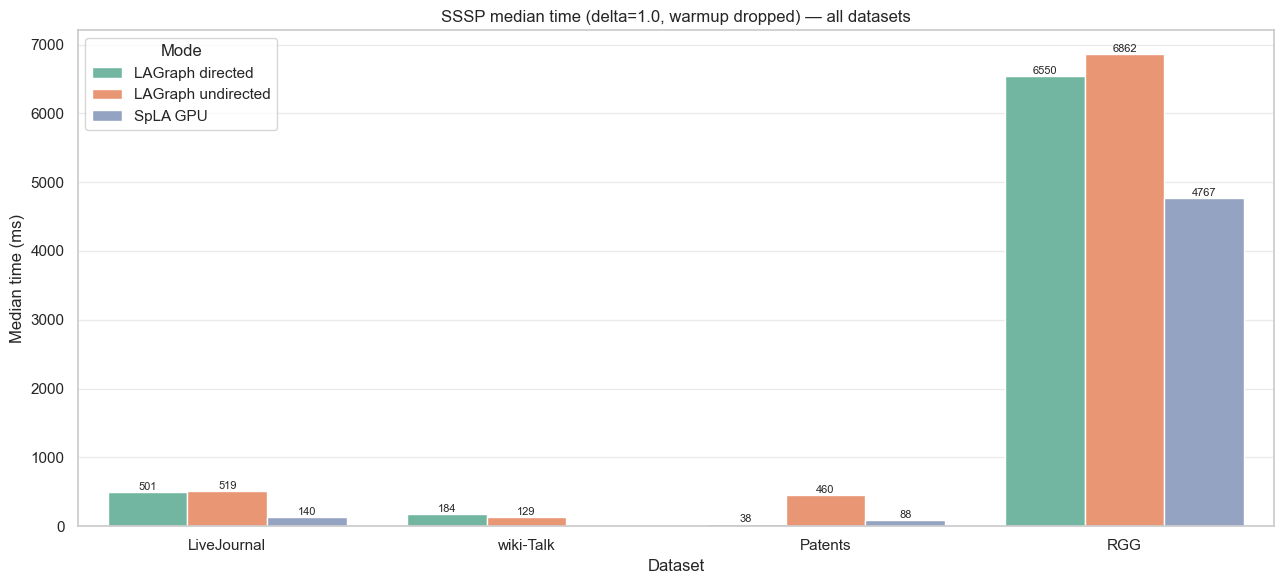

In [4]:
# Chart 1: All datasets × all modes — grouped bar
present_modes  = [m for m in ORDER_MODES  if m in summary['LibraryMode'].values]
graphs_present = [g for g in GRAPHS_ORDER if g in summary['GraphName'].values]

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=summary, x='GraphName', y='Median_ms',
            hue='LibraryMode', hue_order=present_modes,
            order=graphs_present, palette='Set2', ax=ax)
for p in ax.patches:
    h = p.get_height()
    if pd.notna(h) and h > 1:
        ax.annotate(f'{h:.0f}', (p.get_x() + p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=8)
ax.set_title('SSSP median time (delta=1.0, warmup dropped) — all datasets')
ax.set_ylabel('Median time (ms)')
ax.set_xlabel('Dataset')
ax.legend(title='Mode')
ax.grid(axis='y', alpha=0.4)
fig.tight_layout()
fig.savefig(PICS / 'sssp_all_datasets.png', dpi=150)
plt.show()

/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_81794/2516127512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='LibraryMode', y='Time_ms', palette='Set2', ax=ax)
/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_81794/2516127512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='LibraryMode', y='Time_ms', palette='Set2', ax=ax)
/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_81794/2516127512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='LibraryMode', y='Time_ms

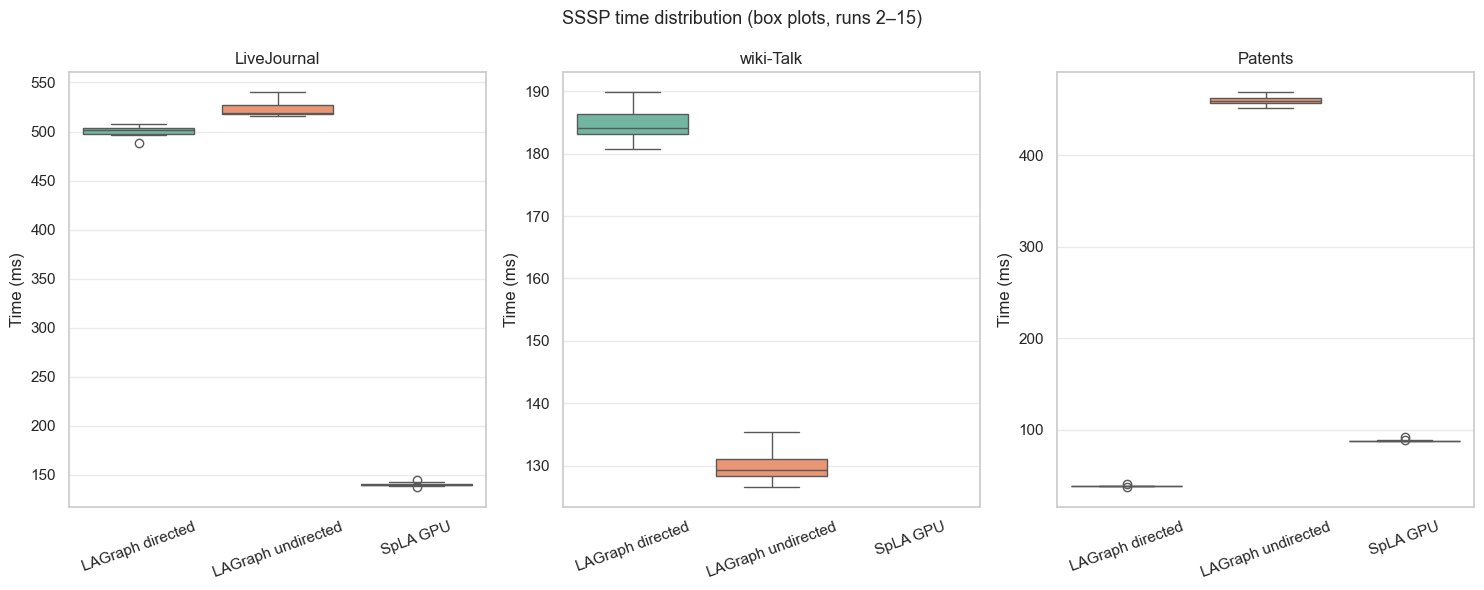

In [5]:
# Chart 2: Box plots — distribution of run times
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, gname in zip(axes, graphs_present):
    sub = df[df['GraphName'] == gname].copy()
    sub['LibraryMode'] = pd.Categorical(sub['LibraryMode'], categories=present_modes, ordered=True)
    sns.boxplot(data=sub, x='LibraryMode', y='Time_ms', palette='Set2', ax=ax)
    ax.set_title(gname)
    ax.set_xlabel('')
    ax.set_ylabel('Time (ms)')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('SSSP time distribution (box plots, runs 2–15)', fontsize=13)
fig.tight_layout()
fig.savefig(PICS / 'sssp_boxplots.png', dpi=150)
plt.show()

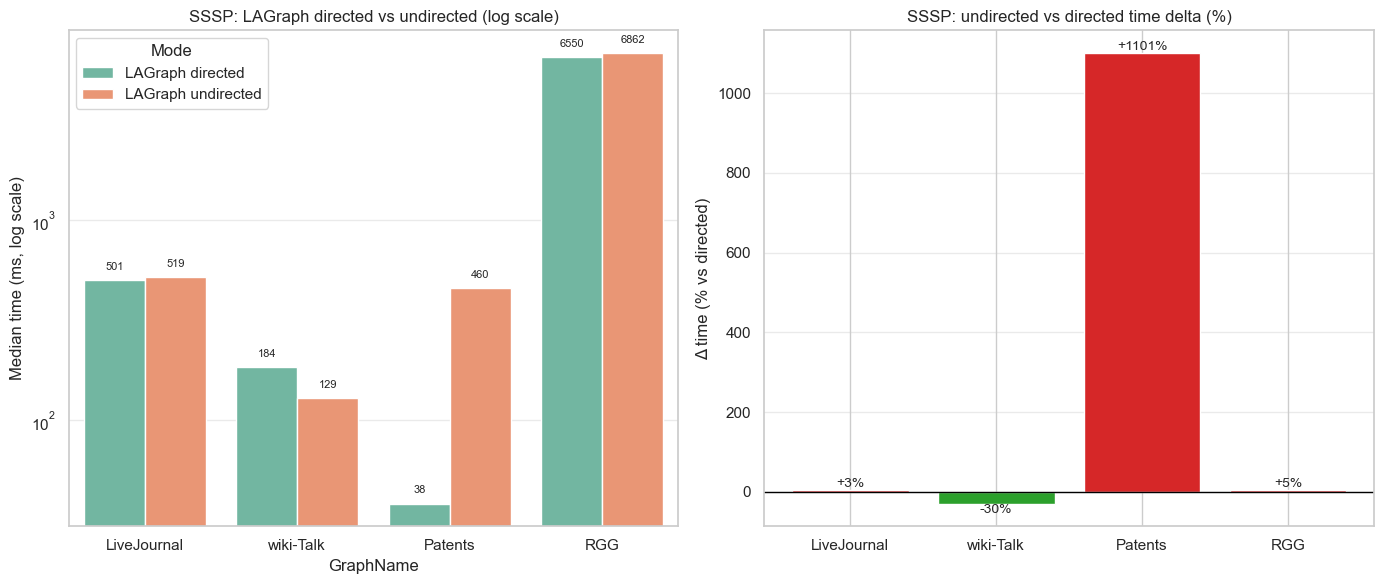

In [6]:
# Chart 3: Directed vs Undirected for LAGraph — log scale (huge differences)
lg = summary[summary['LibraryMode'].isin(['LAGraph directed', 'LAGraph undirected'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: absolute times log scale
sns.barplot(data=lg, x='GraphName', y='Median_ms',
            hue='LibraryMode', hue_order=['LAGraph directed', 'LAGraph undirected'],
            order=graphs_present, palette='Set2', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('SSSP: LAGraph directed vs undirected (log scale)')
axes[0].set_ylabel('Median time (ms, log scale)')
axes[0].legend(title='Mode')
axes[0].grid(axis='y', alpha=0.4)
for p in axes[0].patches:
    h = p.get_height()
    if pd.notna(h) and h > 0:
        axes[0].annotate(f'{h:.0f}', (p.get_x() + p.get_width()/2, h*1.1),
                         ha='center', va='bottom', fontsize=8)

# Right: delta % (undirected vs directed)
piv = lg.pivot_table(index='GraphName', columns='LibraryMode', values='Median_ms').reset_index()
piv.columns.name = None
if 'LAGraph directed' in piv.columns and 'LAGraph undirected' in piv.columns:
    piv['delta_pct'] = (piv['LAGraph undirected'] / piv['LAGraph directed'] - 1) * 100
    piv = piv.dropna(subset=['delta_pct'])
    colors = ['#d62728' if v > 0 else '#2ca02c' for v in piv['delta_pct']]
    bars = axes[1].bar(piv['GraphName'], piv['delta_pct'], color=colors)
    axes[1].axhline(0, color='black', lw=1)
    for bar, v in zip(bars, piv['delta_pct']):
        axes[1].annotate(f'{v:+.0f}%', (bar.get_x() + bar.get_width()/2, v),
                         ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)
    axes[1].set_title('SSSP: undirected vs directed time delta (%)')
    axes[1].set_ylabel('Δ time (% vs directed)')
    axes[1].grid(axis='y', alpha=0.4)

fig.tight_layout()
fig.savefig(PICS / 'sssp_directed_vs_undirected.png', dpi=150)
plt.show()

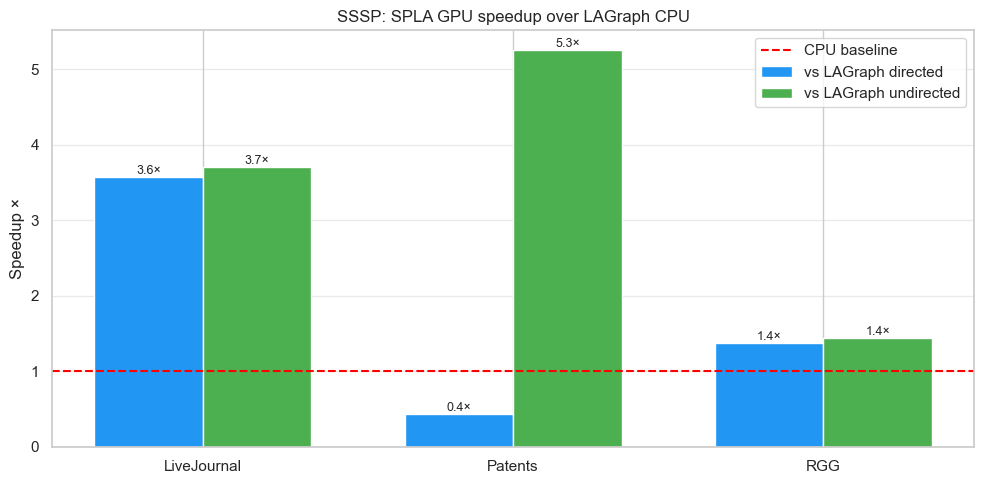

In [7]:
# Chart 4: SPLA GPU speedup over LAGraph CPU (directed)
if 'SpLA GPU' in present_modes:
    spiv = summary.pivot_table(index='GraphName', columns='LibraryMode',
                               values='Median_ms').reset_index()
    spiv.columns.name = None

    if 'LAGraph directed' in spiv.columns and 'SpLA GPU' in spiv.columns:
        spiv['Speedup_vs_directed'] = spiv['LAGraph directed'] / spiv['SpLA GPU']
    if 'LAGraph undirected' in spiv.columns and 'SpLA GPU' in spiv.columns:
        spiv['Speedup_vs_undirected'] = spiv['LAGraph undirected'] / spiv['SpLA GPU']
    
    spiv = spiv.dropna(subset=['Speedup_vs_directed', 'SpLA GPU'])

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(spiv))
    w = 0.35
    if 'Speedup_vs_directed' in spiv.columns:
        b1 = ax.bar(x - w/2, spiv['Speedup_vs_directed'],   w, label='vs LAGraph directed',   color='#2196F3')
    if 'Speedup_vs_undirected' in spiv.columns:
        b2 = ax.bar(x + w/2, spiv['Speedup_vs_undirected'], w, label='vs LAGraph undirected', color='#4CAF50')
    ax.axhline(1.0, color='red', ls='--', lw=1.5, label='CPU baseline')
    ax.set_xticks(x)
    ax.set_xticklabels(spiv['GraphName'])
    ax.set_ylabel('Speedup ×')
    ax.set_title('SSSP: SPLA GPU speedup over LAGraph CPU')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}×', (bar.get_x() + bar.get_width()/2, h),
                        ha='center', va='bottom', fontsize=9)
    fig.tight_layout()
    fig.savefig(PICS / 'sssp_gpu_speedup.png', dpi=150)
    plt.show()

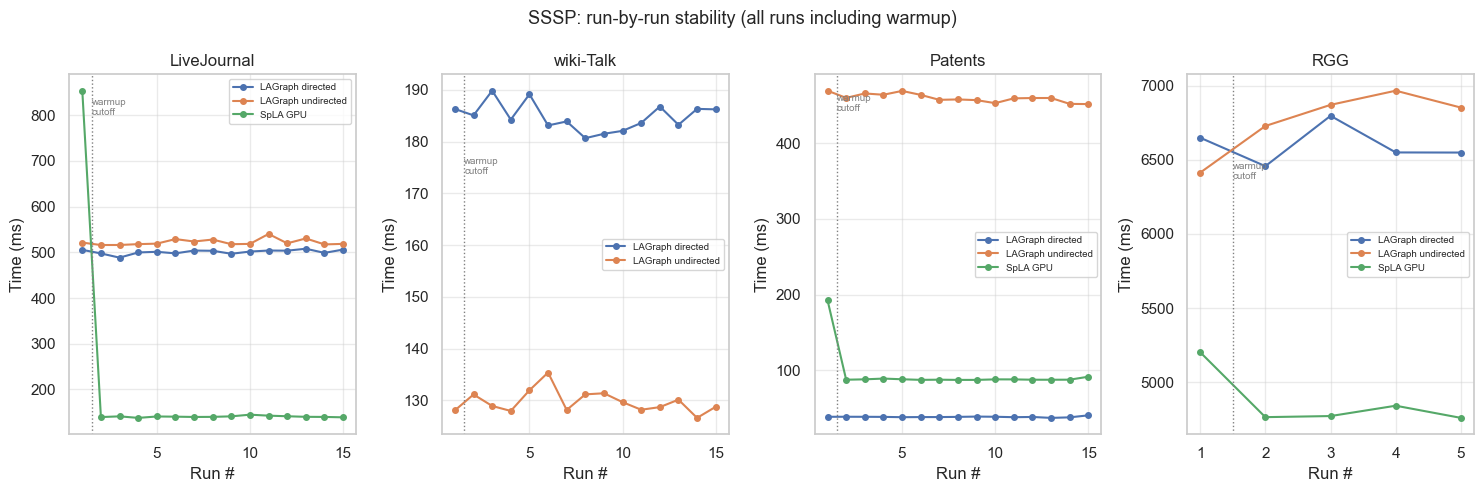

In [8]:
# Chart 5: Stability analysis — run-by-run time series
fig, axes = plt.subplots(1, len(graphs_present), figsize=(15, 5))
if len(graphs_present) == 1:
    axes = [axes]

for ax, gname in zip(axes, graphs_present):
    # Include run 1 to show JIT spike for SpLA
    sub = df_raw[df_raw['GraphName'] == gname].copy()
    sub['LibraryMode'] = pd.Categorical(sub['LibraryMode'], categories=ORDER_MODES, ordered=True)
    for mode, grp in sub.groupby('LibraryMode', observed=True):
        ax.plot(grp['Iteration'], grp['Time_ms'], marker='o', markersize=4, label=mode)
    ax.set_title(gname)
    ax.set_xlabel('Run #')
    ax.set_ylabel('Time (ms)')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.4)
    ax.axvline(1.5, color='grey', ls=':', lw=1)
    ax.annotate('warmup\ncutoff', (1.5, ax.get_ylim()[1]*0.9), fontsize=7, color='grey')

fig.suptitle('SSSP: run-by-run stability (all runs including warmup)', fontsize=13)
fig.tight_layout()
fig.savefig(PICS / 'sssp_stability.png', dpi=150)
plt.show()

In [9]:
print('=' * 65)
print('SSSP FINAL SUMMARY')
print('=' * 65)
for gname in graphs_present:
    sub = summary[summary['GraphName'] == gname]
    if sub.empty:
        continue
    print(f'\n  {gname}')
    for _, row in sub.iterrows():
        ci_h = (row['CI95_high'] - row['CI95_low']) / 2
        print(f'    {row["LibraryMode"]:<25}: {row["Median_ms"]:8.1f} ms '
              f'(±{ci_h:.1f} ms, CV={row["CV_%"]:.1f}%)')

print('\nKey conclusions:')
print('  1. SPLA SSSP requires undirected input — push/pull switching needs AT')
print('  2. LAGraph SSSP supports directed graphs; forward relaxation follows out-edges')
print('  3. Undirected SSSP is slower (more edges relaxed per iteration)')
print('  4. GPU advantage depends on graph density (social >> road/communication)')
print('  5. Delta=1.0 with unit weights: algorithm degenerates to BFS-style relaxation;')
print('     this tests implementation overhead, not algorithmic delta-tuning')

SSSP FINAL SUMMARY

  LiveJournal
    LAGraph directed         :    501.4 ms (±2.8 ms, CV=1.0%)
    LAGraph undirected       :    518.7 ms (±4.1 ms, CV=1.4%)
    SpLA GPU                 :    140.1 ms (±1.0 ms, CV=1.2%)

  wiki-Talk
    LAGraph directed         :    184.1 ms (±1.6 ms, CV=1.5%)
    LAGraph undirected       :    129.3 ms (±1.3 ms, CV=1.7%)

  Patents
    LAGraph directed         :     38.3 ms (±0.4 ms, CV=1.9%)
    LAGraph undirected       :    459.6 ms (±3.0 ms, CV=1.1%)
    SpLA GPU                 :     87.5 ms (±0.6 ms, CV=1.2%)

  RGG
    LAGraph directed         :   6550.0 ms (±232.0 ms, CV=2.2%)
    LAGraph undirected       :   6862.4 ms (±155.8 ms, CV=1.4%)
    SpLA GPU                 :   4767.2 ms (±61.3 ms, CV=0.8%)

Key conclusions:
  1. SPLA SSSP requires undirected input — push/pull switching needs AT
  2. LAGraph SSSP supports directed graphs; forward relaxation follows out-edges
  3. Undirected SSSP is slower (more edges relaxed per iteration)
  4. GPU ad